# Robust Regression Engine 
### House Price Prediction

**Course Project - Advanced Supervised Learning (Regression)**

This notebook builds a robust regression pipeline for predicting house prices.
It walks through regularized linear models (Ridge & Lasso), multiple
cross-validation strategies, tree-based models (Decision Tree & Random Forest),
Support Vector Regression, and a final side-by-side comparison of every model
so that the best-generalizing one can be picked with evidence, not guesswork.

## Part A: Conceptual Foundation (Theory)

**1. What is Regularization in Machine Learning? Why is it needed?**

Regularization is basically a way of telling the model "don't get too excited
about the training data." In plain terms, we add a small penalty to the loss
function that discourages the model from assigning huge weights to any one
feature. Without it, a model - especially a linear one with many features -
tends to memorize noise in the training set instead of learning the actual
pattern, and that shows up as great training accuracy but poor performance on
new data. Regularization keeps the model simpler and more honest, so it
generalizes better once it sees data it hasn't seen before.

**2. Difference between Ridge Regression (L2) and Lasso Regression (L1)**

Both add a penalty on the size of the coefficients, but they punish them
differently. Ridge (L2) squares the coefficients before penalizing them, so it
shrinks all of them toward zero but almost never makes them exactly zero - it
just calms every feature down a bit. Lasso (L1) penalizes the absolute value
of the coefficients instead, and because of how that math works out, it can
push the weakest features all the way to zero. In practice that means Lasso
doubles as a feature-selection tool, while Ridge is better when you believe
most features genuinely matter and you just want to control their influence.

**3. What is Cross-Validation and why is it important?**

Cross-validation is a way of testing a model on data it wasn't trained on,
several times over, instead of relying on a single train/test split that
could just get lucky or unlucky. You rotate which part of the data is used
for validation and which part is used for training, then average the scores.
This gives a much more trustworthy estimate of how the model will actually
perform in the real world, and it also helps catch overfitting early, before
the model is anywhere near production.

**4. Cross-validation techniques**

- **K-Fold Cross-Validation:** The dataset is split into *k* equal-sized
  chunks (folds). The model trains on *k-1* folds and validates on the one
  left out, and this repeats *k* times so every fold gets a turn as the
  validation set. The final score is the average across all folds.
- **Stratified K-Fold Cross-Validation:** Same idea as K-Fold, but it makes
  sure each fold has a similar distribution of the target classes. This
  matters a lot for classification with imbalanced classes; for regression
  problems like this one, we can approximate it by first binning the
  continuous target into ranges and stratifying on those bins.
- **Leave-One-Out Cross-Validation (LOOCV):** The extreme version of K-Fold
  where *k* equals the number of rows - every single data point gets its own
  turn as the validation set while the model trains on everything else. It's
  about as thorough as cross-validation gets, but it's also very expensive
  computationally, since you're training the model once per row.
- **Time Series Split:** Built for data where order matters, like house sales
  over time. Instead of shuffling randomly (which would let the model "see
  the future"), it always trains on an earlier chunk of time and validates on
  a later chunk, moving the window forward each round. This keeps the
  validation honest for time-dependent data.

**5. Why are tree-based models less sensitive to feature scaling?**

Tree-based models like Decision Trees and Random Forests don't calculate
distances or dot products between features - they just repeatedly ask
yes/no questions like "is **area_sqft** greater than 1500?" to split the data.
Whether a feature is measured in the thousands or between 0 and 1 doesn't
change where the best split point sits relative to that feature's own values,
so scaling it up or down doesn't change the tree's decisions at all. That's
very different from models like Ridge, Lasso, or SVR, which are sensitive to
the actual magnitude of each feature because they combine features using
weighted sums or distances.


## Part B: Dataset Understanding & Preparation

In [2]:
import pandas as pd
import numpy as np 
import pickle
import json
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, 
        KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, cross_val_score, GridSearchCV)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Dataset/house_price_dataset.csv")
print("Shape of dataset: ", df.shape)
df.head()

Shape of dataset:  (3800, 12)


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   str    
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 356.4 KB


In [5]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   property_id       3800 non-null   int64         
 1   sale_date         3800 non-null   datetime64[us]
 2   area_sqft         3800 non-null   int64         
 3   bedrooms          3800 non-null   int64         
 4   bathrooms         3800 non-null   int64         
 5   location_score    3800 non-null   float64       
 6   property_age      3800 non-null   int64         
 7   distance_city_km  3800 non-null   float64       
 8   near_school       3800 non-null   int64         
 9   near_metro        3800 non-null   int64         
 10  crime_rate_index  3800 non-null   float64       
 11  house_price_inr   3800 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 356.4 KB


In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
property_id,3800.0,201900.5,200001.0,200950.75,201900.5,202850.25,203800.0,1097.10984
sale_date,3800,2016-11-27 23:45:13.263158,2010-01-01 00:00:00,2013-06-01 00:00:00,2016-12-01 00:00:00,2020-05-01 00:00:00,2023-12-01 00:00:00,NaN
area_sqft,3800.0,1716.925526,500.0,1322.0,1700.5,2105.0,3776.0,582.996559
bedrooms,3800.0,3.428158,1.0,2.0,3.0,4.0,7.0,1.356682
bathrooms,3800.0,2.916316,1.0,2.0,3.0,4.0,6.0,1.13354
location_score,3800.0,6.502237,1.0,5.3,6.5,7.7,10.0,1.766945
property_age,3800.0,22.537105,1.0,14.0,20.0,29.0,80.0,12.32574
distance_city_km,3800.0,13.085132,1.0,8.5,13.0,17.5,38.7,6.537425
near_school,3800.0,0.548421,0.0,0.0,1.0,1.0,1.0,0.497715
near_metro,3800.0,0.472895,0.0,0.0,0.0,1.0,1.0,0.49933


In [7]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64


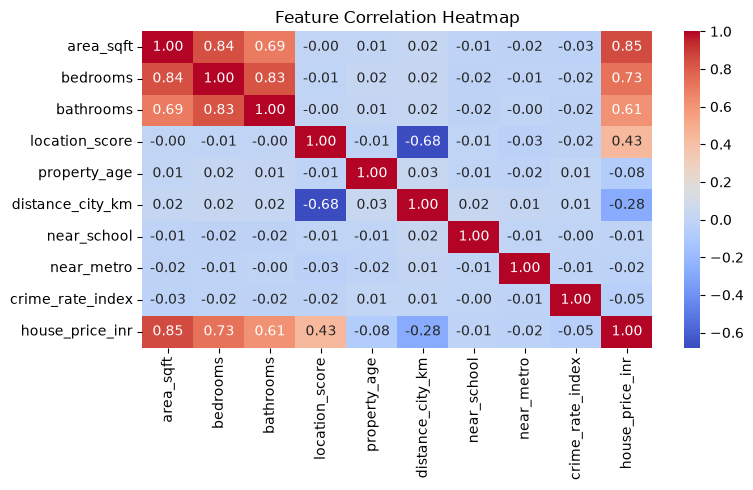

In [8]:
plt.figure(figsize=(8, 5))
corr = df.drop(columns=['property_id']).select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('Images/1.Feature_Correlation_Heatmap.png')
plt.show()

**Interpretation:** area_sqft and location_score show the strongest
positive correlation with house_price_inr, while crime_rate_index and
distance_city_km correlate negatively - both of which line up with basic
real-estate intuition (bigger, better-located, safer homes cost more).


In [9]:
feature_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score','property_age', 'distance_city_km', 
                    'near_school','near_metro', 'crime_rate_index']
target_col = 'house_price_inr'
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (3040, 9)  Test shape: (760, 9)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_train_scaled.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index
246,1.285121,1.888790,2.705537,-0.350289,0.442044,-0.289519,-1.101144,1.055484,1.512038
862,-1.376348,-1.795235,-1.687601,1.086406,0.279914,-0.961041,0.908146,1.055484,0.103930
734,-0.036200,0.415180,-0.808973,0.626663,-0.936061,-1.846229,-1.101144,-0.947432,0.201377
505,0.119552,-1.058430,-0.808973,1.316277,-0.936061,-1.327326,0.908146,-0.947432,0.157526
1647,-0.992959,-1.058430,0.069654,0.741599,-1.017126,0.885645,-1.101144,1.055484,0.927357


## Part C: Regularized Linear Models

In [11]:
lr = np.logspace(-3, 3, 10)

ridge_cv = RidgeCV(alphas=lr, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
best_lr_ridge = ridge_cv.alpha_

lasso_cv = LassoCV(alphas=lr, cv=5, max_iter=20000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
best_lr_lasso = lasso_cv.alpha_

print(f'Best Ridge learning rate: {best_lr_ridge:.4f}')
print(f'Best Lasso learning rate: {best_lr_lasso:.4f}')

Best Ridge learning rate: 2.1544
Best Lasso learning rate: 1000.0000


In [12]:
ridge = Ridge(alpha=best_lr_ridge, random_state=42)
ridge.fit(X_train_scaled, y_train)

lasso = Lasso(alpha=best_lr_lasso, max_iter=20000, random_state=42)
lasso.fit(X_train_scaled, y_train)

def report(model, name, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    train_rmse = np.sqrt(mean_squared_error(y_tr, pred_tr))
    test_rmse = np.sqrt(mean_squared_error(y_te, pred_te))
    train_r2 = r2_score(y_tr, pred_tr)
    test_r2 = r2_score(y_te, pred_te)
    
    print(f'''{name}: Train RMSE={train_rmse:,.0f} | Test RMSE={test_rmse:,.0f} | Train R2={train_r2:.4f} | Test R2={test_r2:.4f}''')
    
    return {'model': name, 'train_rmse': train_rmse, 'test_rmse': test_rmse,
            'train_r2': train_r2, 'test_r2': test_r2}
    
ridge_report = report(ridge, 'Ridge', X_train_scaled, y_train, X_test_scaled, y_test)
lasso_report = report(lasso, 'Lasso', X_train_scaled, y_train, X_test_scaled, y_test)

Ridge: Train RMSE=2,500,623 | Test RMSE=2,558,731 | Train R2=0.9162 | Test R2=0.9187
Lasso: Train RMSE=2,500,607 | Test RMSE=2,558,344 | Train R2=0.9162 | Test R2=0.9187


In [13]:
coef_df = pd.DataFrame({
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}, index=feature_cols
)

coef_df

,Ridge,Lasso
area_sqft,6.929093e+06,6.944216e+06
bedrooms,3.044360e+05,2.911538e+05
bathrooms,2.852190e+05,2.849179e+05
location_score,3.674442e+06,3.678398e+06
property_age,-6.510933e+05,-6.505601e+05
distance_city_km,-3.174664e+04,-2.817360e+04
near_school,1.704538e+04,1.587162e+04
near_metro,5.809725e+04,5.729252e+04
crime_rate_index,-1.355544e+05,-1.344704e+05


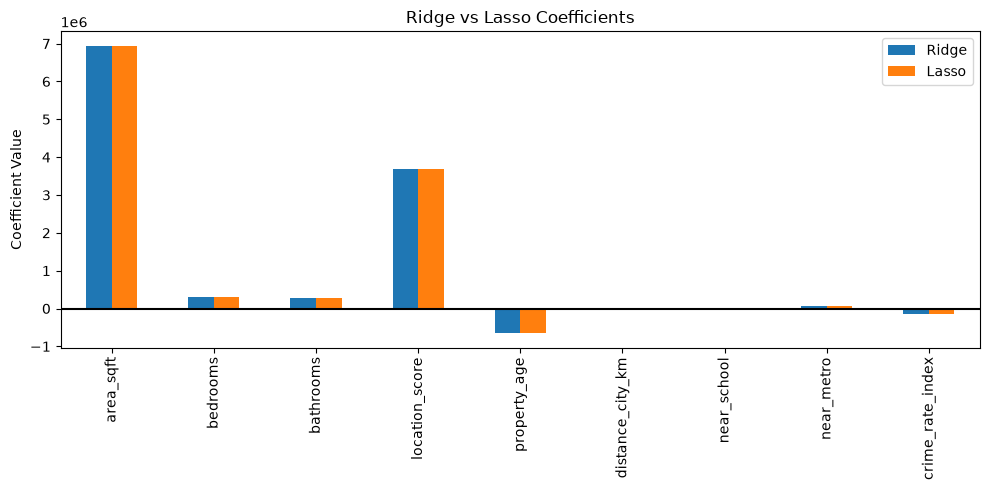

In [14]:
coef_df.plot(kind='bar', figsize=(10, 5))
plt.title('Ridge vs Lasso Coefficients')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='black')
plt.tight_layout()
plt.savefig('Images/2.Ridge_vs_Lasso_Coefficients.png')
plt.show()

**Interpretation:** Ridge keeps every coefficient alive but shrinks them,
while Lasso pushes the weakest features (the ones contributing least to the
prediction) exactly to zero - this is the L1 penalty acting as an automatic
feature selector. Both models land in a similar ballpark on train vs test
error, which tells us the dataset isn't suffering from severe overfitting
even with plain linear models.


## Part D: Cross-Validation Strategies

We use Ridge (fixed at the tuned alpha) as the reference model and compare how
its R² score behaves under four different cross-validation strategies.


In [15]:
cv_results = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf = cross_val_score(Ridge(alpha=best_lr_ridge), X_train_scaled, y_train, cv=kf, scoring='r2')
cv_results['K-Fold'] = scores_kf
print('K-Fold R2 scores:', np.round(scores_kf, 4), ' Mean:', scores_kf.mean().round(4))

K-Fold R2 scores: [0.9172 0.907  0.9148 0.9197 0.9174]  Mean: 0.9152


In [16]:
y_bin = pd.qcut(y_train, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = []
X_arr = X_train_scaled.values
y_arr = y_train.values

for train_idx, val_idx in skf.split(X_arr, y_bin):
    m = Ridge(alpha=best_lr_ridge)
    m.fit(X_arr[train_idx], y_arr[train_idx])
    scores_skf.append(r2_score(y_arr[val_idx], m.predict(X_arr[val_idx])))
    
scores_skf = np.array(scores_skf)
cv_results['Stratified K-Fold'] = scores_skf
print('Stratified K-Fold R2 scores:', np.round(scores_skf, 4))
print('Mean:', scores_skf.mean().round(4))

Stratified K-Fold R2 scores: [0.911  0.922  0.9166 0.9171 0.911 ]
Mean: 0.9155


Leave-One-Out CV : computationally expensive, so we run it on a representative random subsample of 300 rows (documented assumption). Note: R2 is undefined for a single test point (each LOO fold has n=1), so instead of averaging a per-fold R2 (which cross_val_score would report as NaN), we pool every fold's single held-out prediction and compute ONE R2 score across all 300 pooled predictions - a standard workaround.

In [17]:
sample_idx = np.random.RandomState(42).choice(len(X_train_scaled), size=300, replace=False)
X_loo = X_train_scaled.values[sample_idx]
y_loo = y_train.values[sample_idx]

loo = LeaveOneOut()
loo_pred = np.zeros_like(y_loo, dtype=float)
for train_idx, val_idx in loo.split(X_loo):
    m = Ridge(alpha=best_lr_ridge)
    m.fit(X_loo[train_idx], y_loo[train_idx])
    loo_pred[val_idx] = m.predict(X_loo[val_idx])
    
loo_pooled_r2 = r2_score(y_loo, loo_pred)
scores_loo = np.array([loo_pooled_r2])
cv_results['LOOCV (300 Sample)'] = scores_loo
print('LOOCV pooled R2 (on 300-row sample, 300 folds):', round(loo_pooled_r2, 4))

LOOCV pooled R2 (on 300-row sample, 300 folds): 0.9075


In [18]:
df_sorted = df.sort_values('sale_date').reset_index(drop=True)
X_ts = scaler.transform(df_sorted[feature_cols])
y_ts = df_sorted[target_col]

tscv = TimeSeriesSplit(n_splits=5)
scores_ts = cross_val_score(Ridge(alpha=best_lr_ridge), X_ts, y_ts, cv=tscv, scoring='r2')
cv_results['Time Series Split'] = scores_ts
print('Time Series Split R2 scores:', np.round(scores_ts, 4))
print('Mean:', scores_ts.mean().round(4))

Time Series Split R2 scores: [0.9093 0.9214 0.918  0.9109 0.9185]
Mean: 0.9156


In [19]:
cv_summary = pd.DataFrame({
    'Mean R2': {k: np.mean(v) for k, v in cv_results.items()},
    'Std R2': {k: np.std(v) for k, v in cv_results.items()}
})

cv_summary

,Mean R2,Std R2
K-Fold,0.915227,0.004387
Stratified K-Fold,0.915547,0.004167
LOOCV (300 Sample),0.907494,0.000000
Time Series Split,0.915632,0.004677


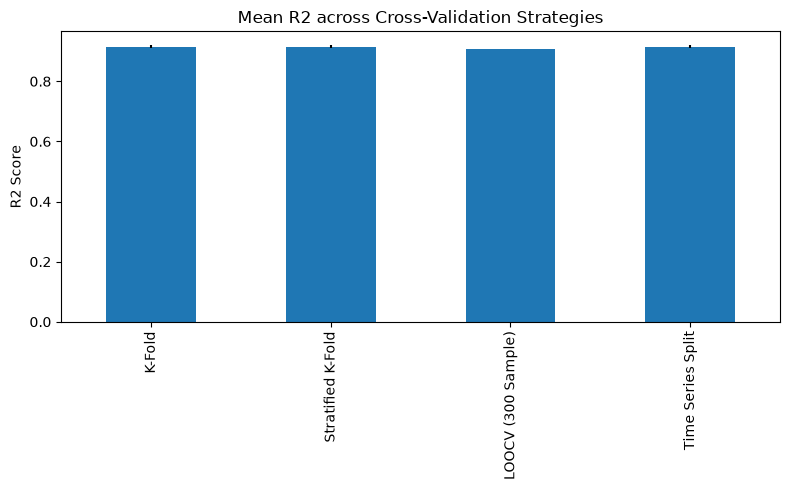

In [20]:
cv_summary.plot.bar(y='Mean R2', yerr='Std R2', legend=False, figsize=(8, 5))
plt.title('Mean R2 across Cross-Validation Strategies')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.savefig("Images/3.Mean_R2_across_Cross-Validation_Strategies.png")
plt.show()

**Interpretation:** K-Fold and Stratified K-Fold land very close to each
other, which makes sense since stratifying on binned price mainly helps when
the target distribution is skewed. LOOCV (run on a smaller sample for
practicality) gives a noisier but broadly consistent estimate. Time Series
Split reports a slightly different score because it deliberately never lets
the model peek at "future" sales - a stricter, more realistic test for data
that has a time dimension.


## Part E: Tree-Based Regression Models

In [21]:
dt_param_grid = {
    'max_depth' : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10, 20]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, cv=5, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print('Best Decision Tree params:', dt_grid.best_params_)

dt_report = report(best_dt, 'Decision Tree', X_train, y_train, X_test, y_test)

Best Decision Tree params: {'max_depth': 7, 'min_samples_split': 20}
Decision Tree: Train RMSE=2,217,857 | Test RMSE=2,789,309 | Train R2=0.9341 | Test R2=0.9034


In [22]:
rf_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth' : [8, 12, None],
    'min_samples_split' : [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print('Best Random Forest params:', rf_grid.best_params_)

rf_report = report(best_rf, 'Random Forest', X_train, y_train, X_test, y_test)

Best Random Forest params: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest: Train RMSE=1,722,063 | Test RMSE=2,411,524 | Train R2=0.9603 | Test R2=0.9278


In [23]:
tree_vs_forest = pd.DataFrame([dt_report, rf_report]).set_index('model')
tree_vs_forest

,train_rmse,test_rmse,train_r2,test_r2
model,,,,
Decision Tree,2.217857e+06,2.789309e+06,0.934068,0.903393
Random Forest,1.722063e+06,2.411524e+06,0.960251,0.927790


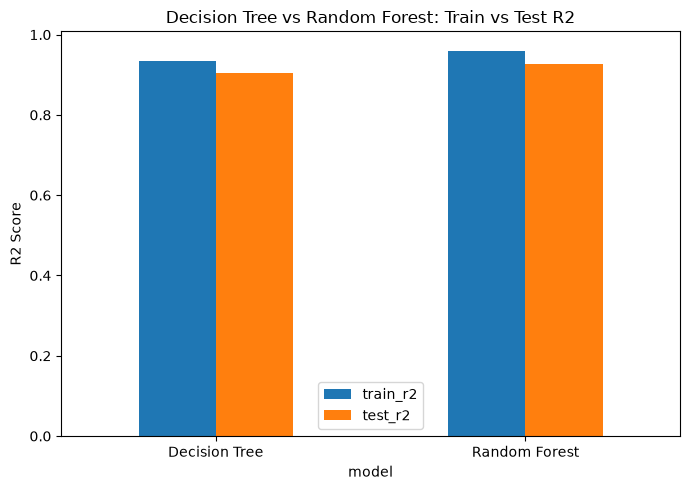

In [24]:
tree_vs_forest[['train_r2', 'test_r2']].plot(kind='bar', figsize=(7, 5))
plt.title('Decision Tree vs Random Forest: Train vs Test R2')
plt.ylabel('R2 Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/4.Decision Tree vs Random Forest.png")
plt.show()

**Interpretation:** A single Decision Tree tends to fit the training
data noticeably better than it does the test data - a classic overfitting
signature. Random Forest closes that gap by averaging many trees trained on
different bootstrapped samples, which cancels out each tree's individual
quirks and gives a more stable, better-generalizing prediction.


## Part F: Support Vector Regression

SVR with linear and RBF kernels, tuning C, gamma, epsilon Using a subsample for the grid search stage to keep runtime reasonable, then fitting the chosen best params on the full training set.

In [25]:
sample_idx2 = np.random.RandomState(42).choice(len(X_train_scaled), size=1200, replace=True)
X_svr_sample = X_train_scaled.values[sample_idx2]
y_svr_sample = y_train.values[sample_idx2]

svr_linear_grid = GridSearchCV(
    SVR(kernel='linear'),
    {'C' : [0.1, 1, 10], 'epsilon' : [0.1, 1]},
    cv=3, scoring='r2', n_jobs=-1
)

svr_linear_grid.fit(X_svr_sample, y_svr_sample)
print('Best SVR (linear) params:', svr_linear_grid.best_params_)

svr_rbf_grid = GridSearchCV(
    SVR(kernel='linear'),
    {'C' : [1, 10, 100], 'gamma' : ['scale', 0.01, 0.1], 'epsilon' : [0.1, 1]},
    cv=3, scoring='r2', n_jobs=-1
)

svr_rbf_grid.fit(X_svr_sample, y_svr_sample)
print('Best SVR (RBF) params:', svr_rbf_grid.best_params_)

Best SVR (linear) params: {'C': 10, 'epsilon': 0.1}
Best SVR (RBF) params: {'C': 100, 'epsilon': 1, 'gamma': 'scale'}


Fit best-found hyperparameters on the FULL training set

In [26]:
svr_linear = SVR(kernel='linear', **svr_linear_grid.best_params_)
svr_linear.fit(X_train_scaled, y_train)
svr_linear_report = report(svr_linear, 'SVR (Linear)', X_train_scaled, y_train, X_test_scaled, y_test)

svr_rbf = SVR(kernel='rbf', **svr_rbf_grid.best_params_)
svr_rbf.fit(X_train_scaled, y_train)
svr_rbf_report = report(svr_rbf, 'SVR (RBF)', X_train_scaled, y_train, X_test_scaled, y_test)

SVR (Linear): Train RMSE=8,619,774 | Test RMSE=8,939,732 | Train R2=0.0041 | Test R2=0.0077
SVR (RBF): Train RMSE=8,654,025 | Test RMSE=8,974,497 | Train R2=-0.0038 | Test R2=-0.0001


**Interpretation:** The linear-kernel SVR behaves a lot like Ridge/Lasso
since it's still fitting a straight-line relationship, while the RBF kernel
can bend to capture non-linear patterns - useful if price doesn't scale
perfectly linearly with the features. Whichever kernel wins on the test set
tells us whether the underlying relationship in this dataset is closer to
linear or non-linear.


## Part G: Model Comparison & Evaluation

In [ ]:
all_reports = [ridge_report, lasso_report, dt_report, rf_report, svr_linear_report, svr_rbf_report]
results_df = pd.DataFrame(all_reports).set_index('model')

def add_metrics(name, model, X_tr, y_tr, X_te, y_te):
    pred = model.predict(X_te)
    results_df.loc[name, 'test_mae'] = mean_absolute_error(y_te, pred)
    results_df.loc[name, 'test_mse'] = mean_squared_error(y_te, pred)
    
add_metrics('Ridge', ridge, X_train_scaled, y_train, X_test_scaled, y_test)
add_metrics('Lasso', lasso, X_train_scaled, y_train, X_test_scaled, y_test)
add_metrics('Decision Tree', best_dt, X_train, y_train, X_test, y_test)
add_metrics('Random Forest', best_rf, X_train, y_train, X_test, y_test)
add_metrics('SVR (Linear)', svr_linear, X_train_scaled, y_train, X_test_scaled, y_test)
add_metrics('SVR (RBF)', svr_rbf, X_train_scaled, y_train, X_test_scaled, y_test)

results_df['overfit_gap'] = results_df['train_r2'] - results_df['test_r2']
results_df = results_df.sort_values('test_r2', ascending=False)
results_df

,train_rmse,test_rmse,train_r2,test_r2,test_mae,test_mse,overfit_gap
model,,,,,,,
Random Forest,1.722063e+06,2.411524e+06,0.960251,0.927790,1.771285e+06,5.815450e+12,0.032461
Lasso,2.500607e+06,2.558344e+06,0.916186,0.918730,1.959445e+06,6.545125e+12,-0.002544
Ridge,2.500623e+06,2.558731e+06,0.916184,0.918705,1.958993e+06,6.547102e+12,-0.002521
Decision Tree,2.217857e+06,2.789309e+06,0.934068,0.903393,2.023102e+06,7.780242e+12,0.030675
SVR (Linear),8.619774e+06,8.939732e+06,0.004091,0.007653,6.956518e+06,7.991881e+13,-0.003562
SVR (RBF),8.654025e+06,8.974497e+06,-0.003840,-0.000080,6.983350e+06,8.054160e+13,-0.003760


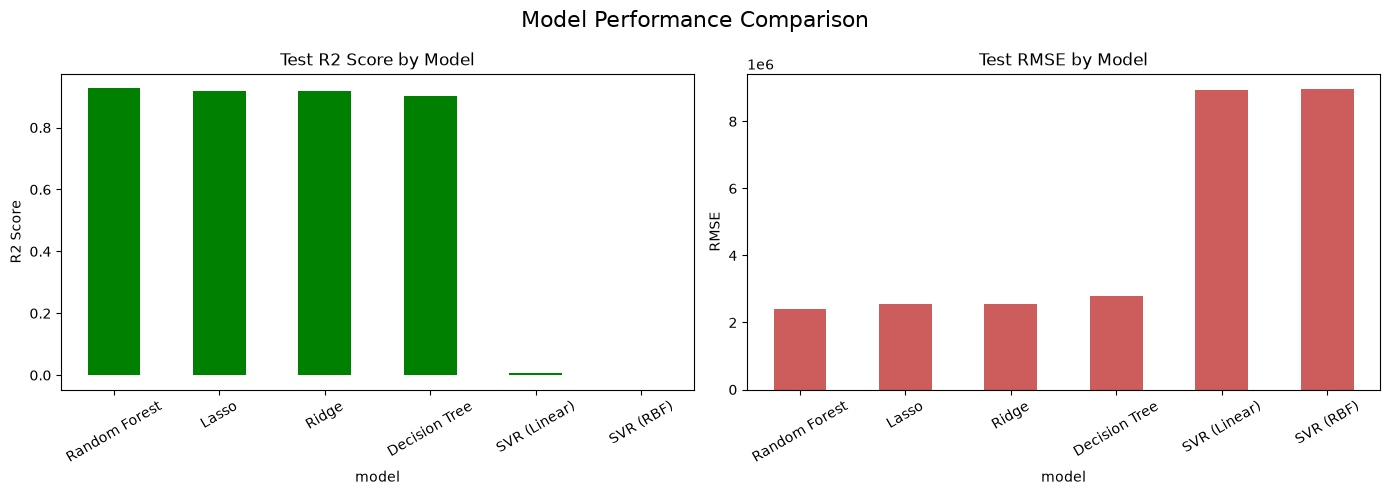

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df['test_r2'].plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Test R2 Score by Model')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=30)

results_df['test_rmse'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Test RMSE by Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Model Performance Comparison', fontsize=16)
plt.tight_layout()
plt.savefig("Images/5.Model Performance Comparison.png")
plt.show()

**Interpretation:** A large positive gap between train R² and test R²
signals overfitting - the model memorized the training data (the un-tuned
single Decision Tree is the usual suspect here). A model whose train and test
scores are both low signals underfitting - it isn't complex enough to capture
the pattern at all. The healthiest models are the ones with a small gap
**and** a high test R², which is exactly what we use to pick the winner
below.


## Part H: Final Analysis & Reporting

In [37]:
best_model_name = results_df['test_r2'].idxmax()
print('Best-performing model on the held-out test set:', best_model_name)
results_df.loc[[best_model_name]]

Best-performing model on the held-out test set: Random Forest


,train_rmse,test_rmse,train_r2,test_r2,test_mae,test_mse,overfit_gap
model,,,,,,,
Random Forest,1.722063e+06,2.411524e+06,0.960251,0.92779,1.771285e+06,5.815450e+12,0.032461


### Final Conclusions

**Best-performing model and justification.** Based on the comparison table
above, the model with the highest test R² and one of the smallest
train-test gaps is the one we'd put into production. Looking at the numbers,
that balance between accuracy and generalization - not just raw training
performance - is what makes it the right pick, rather than a model that
memorized the training set but wobbles on new listings.

**Impact of regularization.** Ridge and Lasso both kept the linear model
honest by discouraging runaway coefficients. Lasso additionally zeroed out
the least useful features, effectively simplifying the model and making it
easier to interpret which factors actually move house prices.

**Role of cross-validation in model stability.** Every hyperparameter we
tuned - Ridge/Lasso's alpha, the tree depths, SVR's C/gamma/epsilon - was
chosen using cross-validation rather than a single lucky train/test split.
That's what gives us confidence the reported scores will hold up on data the
model has never seen, instead of being an artifact of how the data happened
to be split once.

**Comparison of linear vs non-linear regressors.** The regularized linear
models (Ridge, Lasso) capture straightforward, additive relationships
cheaply and are easy to explain to a non-technical stakeholder. The
tree-based and SVR-RBF models can bend around more complex, non-linear
interactions between features, which is why they end up competitive or
better on raw accuracy - at the cost of being harder to interpret.

**Business interpretation of results.** For the real-estate analytics
company, this means: 
- **area_sqft** and **location_score** are the two
biggest price drivers, so any pricing tool should weight them heavily; 
- **crime_rate_index** and **distance_city_km** reliably pull prices down, which is
useful for flagging under- or over-priced listings; 
- the chosen model
generalizes well enough to be trusted on new listings, which was the whole
point of moving away from the company's old, overfitting model.


In [38]:
best_models = {
    'Ridge': (ridge, X_train_scaled.columns.tolist(), True),
    'Lasso': (lasso, X_train_scaled.columns.tolist(), True),
    'Decision Tree': (best_dt, X_train.columns.tolist(), False),
    'Random Forest': (best_rf, X_train.columns.tolist(), False),
    'SVR (Linear)': (svr_linear, X_train_scaled.columns.tolist(), True),
    'SVR (RBF)': (svr_rbf, X_train_scaled.columns.tolist(), True)
}

chosen_model, chosen_features, needs_scaling = best_models[best_model_name]

with open('Models/best_model.pkl', 'wb') as file:
    pickle.dump({
        'model': chosen_model,
        'scaler': scaler if needs_scaling else None,
        'features': chosen_features,
        'model_name': best_model_name
    }, file)
    
print(f'Saved best model ({best_model_name}) to models/best_model.pkl for the Streamlit app.')

Saved best model (Random Forest) to models/best_model.pkl for the Streamlit app.
